In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import h5py as h5

from scipy.optimize import curve_fit

In [2]:
def fit_func(x, a, b):
    return a*x**b

In [ ]:
src_dir = Path("/data/lmp/aarnhold/dynamical_scaling/")
sim = src_dir/"1000.h5"

In [4]:
with h5.File(sim, "r") as fid:
    dset = fid["avg_maxs"]
    
    ydata = dset[0, :]
    xdata = np.arange(len(ydata))


FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/data/lmp/aarnhold/dynamical_scaling/500.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

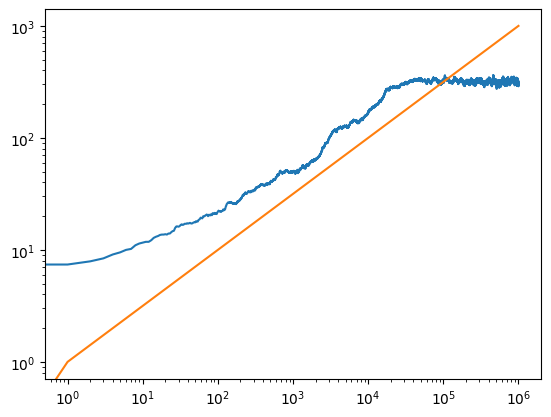

In [5]:
fig, ax = plt.subplots(1, 1)
ax.loglog(xdata, ydata)
ax.loglog(xdata, xdata**(1/2))

k = 0.472


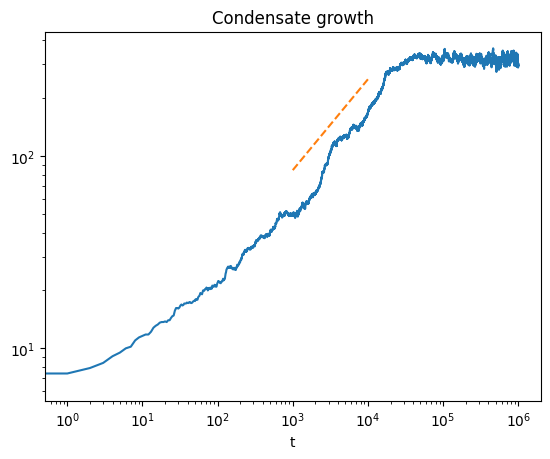

In [6]:
t0, t1 = int(1e3), int(1e4)
popt, pcov = curve_fit(fit_func, xdata[t0:t1], ydata[t0:t1])

fig, ax = plt.subplots(1, 1)
ax.set_title("Condensate growth")
ax.loglog(xdata, ydata, label="data")
ax.loglog(xdata[t0:t1], fit_func(xdata[t0:t1], *popt)*1.5, ls="--")
ax.set_xlabel(r"t")


print(f"k = {popt[1]:.3f}")